# 03 - Hiperparámetros y manejo del entrenamiento

Sección 10 del curso: skorch, CV, Pipeline, GridSearch, checkpoints, early stopping, visualizar el modelo.

Cambios respecto del curso:
- CV por configuración (GroupKFold), lo mismo del leakage del 02 pero dentro del CV
- RandomizedSearchCV además de la grilla
- el radio de corte del descriptor como hiperparámetro (lo análogo al número de capas de la GNN)
- varianza entre semillas antes de decir que algo es mejor
- checkpoints con todo el estado para poder reanudar un job cortado en el cluster

La GNN va a entrenar horas en pirayu con el límite de tiempo de SLURM y con más hiperparámetros (L, hidden, lr, r_c), así que armo la metodología ahora con el MLP que tarda segundos.

Necesita datos/02_dataset.pt (sale del 02). Tarda unos 4 min con 16 núcleos; en Colab con 2 núcleos calculo 15 a 25 min.

## Imports

In [1]:
try:
    import skorch
except ImportError:
    %pip install -q skorch
    import skorch

import copy, shutil, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from skorch import NeuralNetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import (GroupKFold, KFold, cross_validate,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import make_scorer
from scipy.stats import loguniform, uniform

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| skorch", skorch.__version__, "|", device)

torch 2.12.0+cu130 | skorch 1.4.0 | cpu


In [2]:
d = torch.load("datos/02_dataset.pt")
L, ELEMENTOS, R_C_VEC = d["L"], d["elementos"], d["R_C_VEC"]
print(len(d["configs"]), "configuraciones |",
      "train/val/test:", len(d["conf_train"]), len(d["conf_val"]), len(d["conf_test"]))

80 configuraciones | train/val/test: 56 12 12


## G2 con r_cut variable

Igual que en el 02 pero r_cut ahora es argumento para poder barrerlo. Los RS van cada 0.2 Å desde 2 Å hasta r_cut, así que más radio = más columnas.

In [3]:
def dif_pbc(dr):
    return dr - L * torch.round(dr / L)

def descriptores_G2(pos, r_cut, ancho=0.15, paso=0.2):
    RS = torch.arange(2.0, r_cut - 0.1, paso)
    eta = 1 / (2 * ancho**2)
    r = torch.linalg.norm(dif_pbc(pos[:, None] - pos[None]), dim=-1)
    fc = 0.5 * (torch.cos(torch.pi * r / r_cut) + 1) * ((r > 0) & (r < r_cut))
    G = (torch.exp(-eta * (r[..., None] - RS) ** 2) * fc[..., None]).sum(dim=1)
    coord = ((r > 0) & (r < R_C_VEC)).sum(dim=1, keepdim=True).float()
    return G, coord

def construir(r_cut):
    # Devuelve arrays numpy, el formato que esperan scikit-learn y skorch.
    X, y, grupo, vecino, sigma = [], [], [], [], []
    for c, cfg in enumerate(d["configs"]):
        G, coord = descriptores_G2(cfg["pos"], r_cut)
        X.append(torch.cat([F.one_hot(cfg["species"], len(ELEMENTOS)).float(), coord, G], dim=1))
        y.append(100 * cfg["dv"])
        grupo.append(torch.full_like(cfg["species"], c))
        vecino.append(cfg["vecino_vac"])
        sigma.append(torch.full_like(cfg["dv"], cfg["sigma"]))
    cat = lambda t: torch.cat(t).numpy()
    return (cat(X).astype(np.float32), cat(y).astype(np.float32).reshape(-1, 1),
            cat(grupo), cat(vecino), cat(sigma))

X, y, grupo, vecino, sigma = construir(r_cut=5.0)
tv = np.isin(grupo, torch.cat([d["conf_train"], d["conf_val"]]).numpy())   # train+val: para el CV
te = np.isin(grupo, d["conf_test"].numpy())                                 # test: NO se toca hasta el final
print("X:", X.shape, "| train+val:", tv.sum(), "| test:", te.sum())

X: (20223, 21) | train+val: 17191 | test: 3032


## MLP con skorch

NeuralNetRegressor envuelve el nn.Module como en el curso. Lo meto en un Pipeline con StandardScaler para que el escalado se ajuste dentro de cada fold con su parte de train; si escalo todo antes se filtra info del fold de validación.

Ahora el MLP recibe n_layers y la activación para poder buscarlos. Con los defaults es el mismo del 02.

In [4]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden=64, n_layers=2, p_drop=0.05, activation=nn.SiLU):
        super().__init__()
        capas, d_in = [], n_in
        for _ in range(n_layers):
            capas += [nn.Linear(d_in, hidden), activation(), nn.Dropout(p_drop)]
            d_in = hidden
        capas.append(nn.Linear(d_in, 1))
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        return self.red(x)

def a_float32(X):
    return X.astype(np.float32)          # StandardScaler devuelve float64; PyTorch quiere float32

def crear_pipeline(n_in, **kw):
    red = NeuralNetRegressor(
        MLP, module__n_in=n_in,
        criterion=nn.HuberLoss, optimizer=optim.AdamW, lr=3e-3,
        max_epochs=40, batch_size=256,
        train_split=None,                 # la validación la hace el CV de afuera
        iterator_train__shuffle=True,
        device=device, verbose=0, **kw)
    return Pipeline([("escalar", StandardScaler()),
                     ("float32", FunctionTransformer(a_float32)),
                     ("red", red)])

Métricas: el MAE global lo domina el bulk (~85 %). Agrego el MAE de la cola, el error en átomos con Δv > 4 %, que son los que importan para encontrar defectos. Depende solo del target, así que no necesita saber quién es vecino de vacancia y sirve igual con datos reales.

In [5]:
def mae_cola(y_true, y_pred, umbral=4.0):
    m = y_true.ravel() > umbral
    return np.abs(y_true.ravel()[m] - y_pred.ravel()[m]).mean()

SCORING = {"mae": "neg_mean_absolute_error",
           "mae_cola": make_scorer(mae_cola, greater_is_better=False)}

def resumen(cv, prefijo="test_"):
    return {k: f"{-cv[prefijo + k].mean():.3f} ± {cv[prefijo + k].std():.3f} %" for k in SCORING}

## KFold vs GroupKFold

GroupKFold deja todos los átomos de una configuración en el mismo fold. KFold los mezcla como en el curso. Si KFold da menos error, esa diferencia es lo que infla el leakage.

In [6]:
Xtv, ytv, gtv = X[tv], y[tv], grupo[tv]

t0 = time.time()
cv_kfold = cross_validate(crear_pipeline(X.shape[1]), Xtv, ytv, scoring=SCORING,
                          cv=KFold(4, shuffle=True, random_state=0), n_jobs=-1)
cv_group = cross_validate(crear_pipeline(X.shape[1]), Xtv, ytv, groups=gtv, scoring=SCORING,
                          cv=GroupKFold(4), n_jobs=-1)
print("KFold (por átomo)       ", resumen(cv_kfold))
print("GroupKFold (por config.)", resumen(cv_group))
print(f"[{time.time() - t0:.0f} s]")

KFold (por átomo)        {'mae': '0.384 ± 0.006 %', 'mae_cola': '0.768 ± 0.023 %'}
GroupKFold (por config.) {'mae': '0.415 ± 0.087 %', 'mae_cola': '0.830 ± 0.168 %'}
[19 s]


La diferencia da chica porque las cajas son independientes y estadísticamente iguales. Con trayectorias reales de MD puede ser mucho más grande porque frames seguidos son casi iguales. En la tesis agrupar siempre por trayectoria o simulación.

## Grid search

Barro lr y hidden. Dentro de un Pipeline los nombres en skorch son paso__parámetro, y para los argumentos del modelo red__module__nombre.

[42 s]  mejor: {'red__lr': 0.001, 'red__module__hidden': 128}  MAE=0.387 %


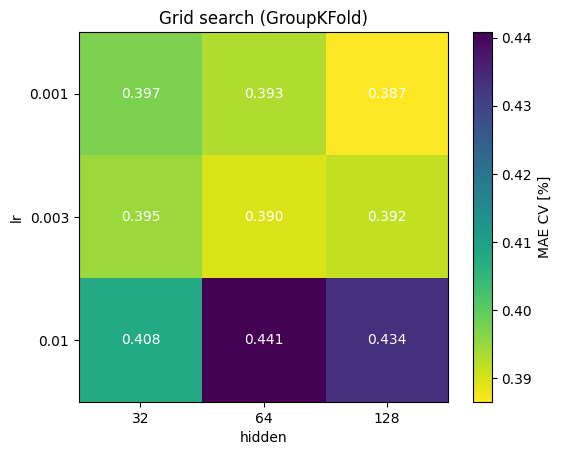

In [7]:
param_grid = {
    "red__lr":             [1e-3, 3e-3, 1e-2],
    "red__module__hidden": [32, 64, 128],
}
t0 = time.time()
grid = GridSearchCV(crear_pipeline(X.shape[1]), param_grid, scoring=SCORING, refit="mae",
                    cv=GroupKFold(4), n_jobs=-1)
grid.fit(Xtv, ytv, groups=gtv)
print(f"[{time.time() - t0:.0f} s]  mejor: {grid.best_params_}  MAE={-grid.best_score_:.3f} %")

tabla = -grid.cv_results_["mean_test_mae"].reshape(len(param_grid["red__lr"]), -1)
plt.imshow(tabla, cmap="viridis_r")
plt.xticks(range(3), param_grid["red__module__hidden"]); plt.yticks(range(3), param_grid["red__lr"])
plt.xlabel("hidden"); plt.ylabel("lr"); plt.colorbar(label="MAE CV [%]")
for (i, j), v in np.ndenumerate(tabla):
    plt.text(j, i, f"{v:.3f}", ha="center", va="center", color="w")
plt.title("Grid search (GroupKFold)"); plt.show()

## Random search

La grilla usa 9 entrenamientos y prueba solo 3 valores de cada hiperparámetro. Con el mismo presupuesto el random prueba 9 valores distintos de cada uno (Bergstra y Bengio 2012), y eso importa cuando solo algunos hiperparámetros pesan, que es lo normal.

lr y weight_decay en escala log (loguniform) porque importa el orden de magnitud. Activación y profundidad como listas.

In [8]:
param_dist = {
    "red__lr":                     loguniform(3e-4, 3e-2),
    "red__optimizer__weight_decay": loguniform(1e-6, 1e-2),
    "red__module__hidden":         [32, 64, 128, 256],
    "red__module__n_layers":       [1, 2, 3],
    "red__module__p_drop":         uniform(0.0, 0.3),
    "red__module__activation":     [nn.ReLU, nn.SiLU, nn.Tanh],
}
t0 = time.time()
busqueda = RandomizedSearchCV(crear_pipeline(X.shape[1]), param_dist, n_iter=16, scoring=SCORING,
                              refit="mae", cv=GroupKFold(4), n_jobs=-1, random_state=0)
busqueda.fit(Xtv, ytv, groups=gtv)
print(f"[{time.time() - t0:.0f} s]")

res = busqueda.cv_results_
orden = np.argsort(-res["mean_test_mae"])
print(f"{'MAE':>7s} {'cola':>7s} {'lr':>8s} {'wd':>8s} {'hid':>4s} {'cap':>3s} {'drop':>5s}  act")
for k in orden[:8]:
    p = res["params"][k]
    print(f"{-res['mean_test_mae'][k]:7.3f} {-res['mean_test_mae_cola'][k]:7.3f} {p['red__lr']:8.1e} "
          f"{p['red__optimizer__weight_decay']:8.1e} {p['red__module__hidden']:4d} {p['red__module__n_layers']:3d} "
          f"{p['red__module__p_drop']:5.2f}  {p['red__module__activation'].__name__}")

[63 s]
    MAE    cola       lr       wd  hid cap  drop  act
  0.390   0.785  4.1e-03  4.1e-04  256   1  0.29  ReLU
  0.392   0.780  5.6e-03  7.3e-05   32   1  0.08  ReLU
  0.393   0.790  9.2e-04  1.3e-03   64   2  0.10  SiLU
  0.398   0.786  2.4e-03  7.6e-03   64   2  0.03  ReLU
  0.400   0.796  5.7e-03  4.6e-05   64   1  0.16  SiLU
  0.404   0.815  3.4e-03  2.2e-05   64   2  0.25  ReLU
  0.418   0.853  1.2e-03  1.5e-03   32   1  0.12  ReLU
  0.420   0.792  3.8e-03  3.4e-05   32   2  0.19  SiLU


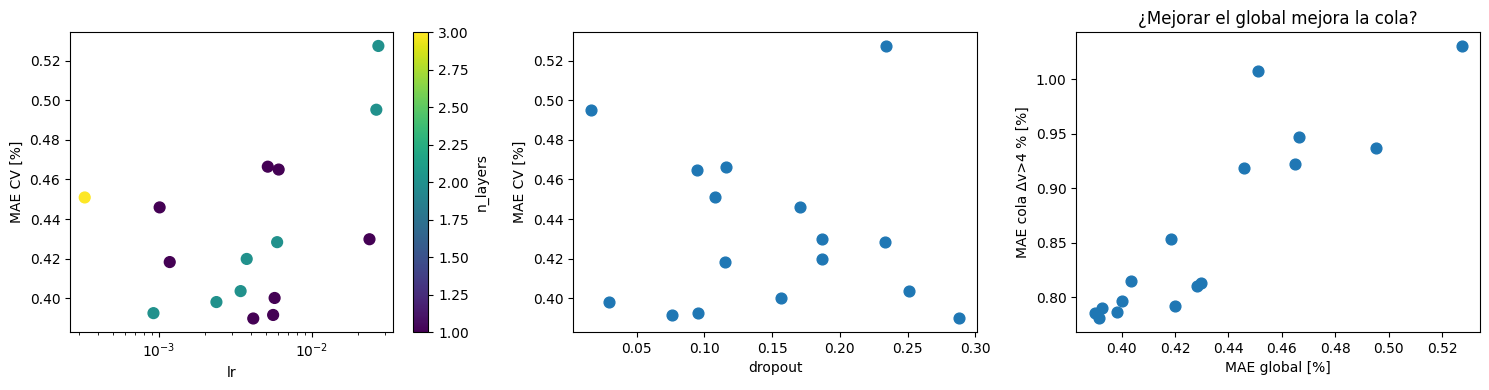

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
lrs = np.array([p["red__lr"] for p in res["params"]])
drops = np.array([p["red__module__p_drop"] for p in res["params"]])
capas = np.array([p["red__module__n_layers"] for p in res["params"]])
mae_cv = -res["mean_test_mae"]

sc = ax[0].scatter(lrs, mae_cv, c=capas, cmap="viridis", s=60)
ax[0].set_xscale("log"); ax[0].set_xlabel("lr"); ax[0].set_ylabel("MAE CV [%]")
fig.colorbar(sc, ax=ax[0], label="n_layers")
ax[1].scatter(drops, mae_cv, s=60); ax[1].set_xlabel("dropout"); ax[1].set_ylabel("MAE CV [%]")
ax[2].scatter(mae_cv, -res["mean_test_mae_cola"], s=60)
ax[2].set_xlabel("MAE global [%]"); ax[2].set_ylabel("MAE cola Δv>4 % [%]")
ax[2].set_title("¿Mejorar el global mejora la cola?")
plt.tight_layout(); plt.show()

In [10]:
print(f"grid   (9 combinaciones, 2 hiperparámetros): mejor MAE = {-grid.best_score_:.3f} %")
print(f"random (16 muestras, 6 hiperparámetros):     mejor MAE = {-busqueda.best_score_:.3f} %")

grid   (9 combinaciones, 2 hiperparámetros): mejor MAE = 0.387 %
random (16 muestras, 6 hiperparámetros):     mejor MAE = 0.390 %


Si gana la grilla no es contradicción: estaba centrada en valores que ya sabía que andaban (los del 02), y el random exploró 6 dimensiones con 16 muestras y gastó varias en zonas malas. El random sirve cuando no sé dónde está el óptimo, que va a ser el caso de la GNN. Lo razonable es primero random amplio y después algo fino alrededor.

Qué miro en los gráficos antes de quedarme con el mejor:
- si el óptimo cae en el borde de algún rango, el rango estaba mal
- si hay algún hiperparámetro que no cambia nada, lo fijo y listo
- si el MAE global y el de la cola no van juntos, optimizar el global no asegura mejor detección y conviene refit="mae_cola"

## r_cut

r_cut es cuánto entorno ve cada átomo; en la GNN sería L capas por el radio del grafo. Barriéndolo con el MLP veo a partir de qué distancia ya no hay información sobre Δv, y con eso elijo L para la GIN (en CONTEXTO.md puse L = 4).

r_cut=3.0 Å  (11 columnas)  MAE=0.479  cola=1.009


r_cut=3.8 Å  (15 columnas)  MAE=0.386  cola=0.777


r_cut=4.6 Å  (19 columnas)  MAE=0.393  cola=0.794


r_cut=5.4 Å  (23 columnas)  MAE=0.391  cola=0.776


r_cut=6.2 Å  (27 columnas)  MAE=0.394  cola=0.786
[34 s]


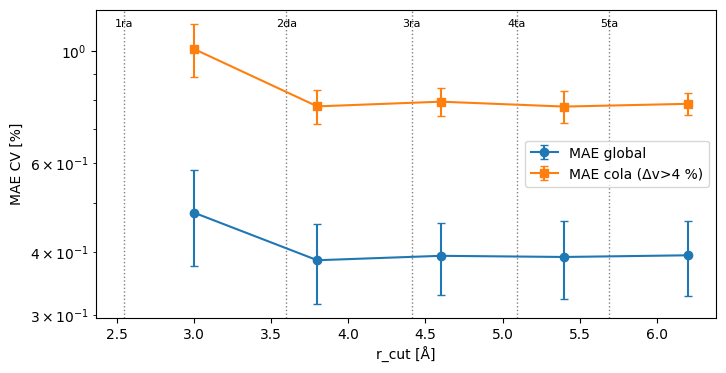

In [11]:
mejores = {k: v for k, v in busqueda.best_params_.items()}
capas_fcc = {"1ra": 2.55, "2da": 3.60, "3ra": 4.41, "4ta": 5.09, "5ta": 5.69}

radios, filas_rc = [3.0, 3.8, 4.6, 5.4, 6.2], []
t0 = time.time()
for rc in radios:
    Xr = construir(rc)[0]
    pipe = crear_pipeline(Xr.shape[1]).set_params(**mejores)
    cv = cross_validate(pipe, Xr[tv], ytv, groups=gtv, scoring=SCORING, cv=GroupKFold(4), n_jobs=-1)
    filas_rc.append((-cv["test_mae"].mean(), cv["test_mae"].std(), -cv["test_mae_cola"].mean(), cv["test_mae_cola"].std()))
    print(f"r_cut={rc:.1f} Å  ({Xr.shape[1]} columnas)  MAE={filas_rc[-1][0]:.3f}  cola={filas_rc[-1][2]:.3f}")
print(f"[{time.time() - t0:.0f} s]")

f = np.array(filas_rc)
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(radios, f[:, 0], f[:, 1], marker="o", capsize=3, label="MAE global")
ax.errorbar(radios, f[:, 2], f[:, 3], marker="s", capsize=3, label="MAE cola (Δv>4 %)")
for nombre, r in capas_fcc.items():
    ax.axvline(r, color="gray", ls=":", lw=1); ax.text(r, ax.get_ylim()[1] * 0.95, nombre, ha="center", fontsize=8)
ax.set_xlabel("r_cut [Å]"); ax.set_ylabel("MAE CV [%]"); ax.set_yscale("log"); ax.legend(); plt.show()

## Ruido entre semillas

Antes de decir que A es mejor que B necesito saber cuánto cambia el resultado con la misma configuración y otra semilla (init de pesos, orden de los batches). Si A − B es menor que eso, no hay diferencia real. Para el paper: media ± desvío sobre varias semillas.

In [12]:
R_CUT = radios[int(np.argmin(f[:, 0]))]
X, y, grupo, vecino, sigma = construir(R_CUT)
tr = np.isin(grupo, d["conf_train"].numpy())
va = np.isin(grupo, d["conf_val"].numpy())

maes = []
for seed in range(5):
    torch.manual_seed(seed)
    pipe = crear_pipeline(X.shape[1]).set_params(**mejores).fit(X[tr], y[tr])
    maes.append(np.abs(pipe.predict(X[va]) - y[va]).mean())
maes = np.array(maes)
print(f"r_cut elegido = {R_CUT} Å")
print("MAE val por semilla:", np.round(maes, 4))
print(f"media ± desvío = {maes.mean():.4f} ± {maes.std():.4f} %")

top = np.sort(mae_cv)[:5]
print("las 5 mejores del random search:", np.round(top, 4), "-> separación entre 1ra y 5ta:", round(top[4] - top[0], 4))

r_cut elegido = 3.8 Å
MAE val por semilla: [0.3202 0.3014 0.3233 0.2979 0.3113]
media ± desvío = 0.3108 ± 0.0100 %
las 5 mejores del random search: [0.3898 0.3916 0.3925 0.3981 0.4002] -> separación entre 1ra y 5ta: 0.0104


## Checkpoints reanudables

En pirayu el job se corta cuando llega al --time. Para seguir exactamente donde quedó no alcanza con los pesos (que es lo que guarda el curso), hace falta:
- model.state_dict()
- optimizer.state_dict(), los momentos de Adam (si no, arranca en frío)
- scheduler.state_dict(), lr actual y contador de paciencia
- época, historial, mejor métrica y contador de early stopping
- estado del RNG global y del DataLoader, para tener el mismo orden de batches y el mismo dropout

También guardo en cada época el MAE por población (bulk y vecinos de vacancia).

In [13]:
def entrenar_gestionado(cfg, Xtr, ytr, Xva, yva, vva, carpeta, max_epochs=200, paciencia=25,
                        parar_en=None, seed=0):
    carpeta = Path(carpeta); carpeta.mkdir(parents=True, exist_ok=True)
    ultimo, mejor = carpeta / "ultimo.pt", carpeta / "mejor.pt"

    torch.manual_seed(seed)
    model = MLP(Xtr.shape[1], **cfg["module"]).to(device)
    opt = optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=8)
    gen = torch.Generator().manual_seed(seed)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True, generator=gen)
    loss_fn = nn.HuberLoss()
    Xva, yva = Xva.to(device), yva.to(device)

    estado = {"epoch": 0, "mejor": np.inf, "sin_mejora": 0, "terminado": False,
              "hist": {k: [] for k in ("train", "val", "val_bulk", "val_vac", "lr")}}

    if ultimo.exists():                                         # ---- reanudar ----
        ck = torch.load(ultimo, weights_only=False)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["optimizer"])
        sched.load_state_dict(ck["scheduler"]); estado = ck["estado"]
        torch.set_rng_state(ck["rng"]); gen.set_state(ck["rng_loader"])
        if torch.cuda.is_available(): torch.cuda.set_rng_state_all(ck["rng_cuda"])
        print(f"reanudando desde la época {estado['epoch']}")

    while not estado["terminado"] and estado["epoch"] < max_epochs:
        if parar_en is not None and estado["epoch"] >= parar_en:
            print(f"corte en la época {estado['epoch']} (simula el fin del --time de SLURM)")
            return model, estado

        model.train(); perdidas = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            perdidas.append(loss.item())

        model.eval()
        with torch.no_grad():
            err = (model(Xva) - yva).abs().squeeze().cpu()
        val = err.mean().item()
        sched.step(val)

        h = estado["hist"]
        h["train"].append(np.mean(perdidas)); h["val"].append(val)
        h["val_bulk"].append(err[~vva].mean().item()); h["val_vac"].append(err[vva].mean().item())
        h["lr"].append(opt.param_groups[0]["lr"])
        estado["epoch"] += 1

        if val < estado["mejor"]:
            estado["mejor"], estado["sin_mejora"] = val, 0
            torch.save(model.state_dict(), mejor)
        else:
            estado["sin_mejora"] += 1
            if estado["sin_mejora"] >= paciencia:
                estado["terminado"] = True
                print(f"early stopping en la época {estado['epoch']} (mejor val MAE = {estado['mejor']:.4f} %)")

        torch.save({"model": model.state_dict(), "optimizer": opt.state_dict(),
                    "scheduler": sched.state_dict(), "estado": estado,
                    "rng": torch.get_rng_state(), "rng_loader": gen.get_state(),
                    "rng_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None},
                   ultimo)

    model.load_state_dict(torch.load(mejor))
    return model, estado

Estandarizo con train y paso los mejores hiperparámetros del random search al formato de la función.

In [14]:
mu, sd = X[tr].mean(0), X[tr].std(0).clip(1e-6)
T = lambda a: torch.from_numpy(a)
Xtr_t, Xva_t, Xte_t = (T((X[m] - mu) / sd) for m in (tr, va, te))
ytr_t, yva_t, yte_t = T(y[tr]), T(y[va]), T(y[te])
vva_t, vte_t = T(vecino[va]), T(vecino[te])

cfg = {"lr": mejores["red__lr"], "weight_decay": mejores["red__optimizer__weight_decay"],
       "module": {k.split("__")[-1]: v for k, v in mejores.items() if k.startswith("red__module__")}}
print(cfg)

{'lr': np.float64(0.004144907046772437), 'weight_decay': np.float64(0.0004084710370903228), 'module': {'activation': <class 'torch.nn.modules.activation.ReLU'>, 'hidden': 256, 'n_layers': 1, 'p_drop': np.float64(0.2876847805873561)}}


Prueba de reanudación: A entrena de corrido, B se corta en la época 30 y se vuelve a llamar igual, como un job reencolado. Si el checkpoint está completo los pesos de A y B tienen que dar idénticos.

In [15]:
for c in ("checkpoints/A", "checkpoints/B"):
    shutil.rmtree(c, ignore_errors=True)

model_A, est_A = entrenar_gestionado(cfg, Xtr_t, ytr_t, Xva_t, yva_t, vva_t, "checkpoints/A")

entrenar_gestionado(cfg, Xtr_t, ytr_t, Xva_t, yva_t, vva_t, "checkpoints/B", parar_en=30)   # job 1
model_B, est_B = entrenar_gestionado(cfg, Xtr_t, ytr_t, Xva_t, yva_t, vva_t, "checkpoints/B")  # job 2

iguales = all(torch.equal(a, b) for a, b in zip(model_A.state_dict().values(), model_B.state_dict().values()))
print("épocas A / B:", est_A["epoch"], "/", est_B["epoch"], "| pesos idénticos:", iguales)

early stopping en la época 95 (mejor val MAE = 0.2912 %)


corte en la época 30 (simula el fin del --time de SLURM)
reanudando desde la época 30


early stopping en la época 95 (mejor val MAE = 0.2912 %)
épocas A / B: 95 / 95 | pesos idénticos: True


En GPU hay operaciones no deterministas, así que A y B pueden diferir en el último decimal. Si hace falta igualdad exacta está torch.use_deterministic_algorithms(True), pero es más lento.

Curvas por población:

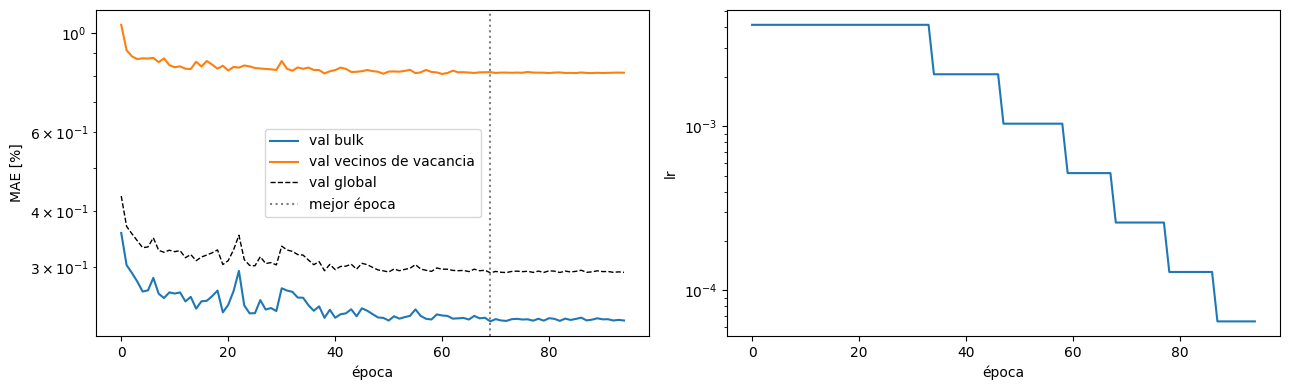

In [16]:
h = est_A["hist"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h["val_bulk"], label="val bulk"); ax[0].plot(h["val_vac"], label="val vecinos de vacancia")
ax[0].plot(h["val"], "k--", lw=1, label="val global")
ax[0].axvline(int(np.argmin(h["val"])), color="gray", ls=":", label="mejor época")
ax[0].set_yscale("log"); ax[0].set_xlabel("época"); ax[0].set_ylabel("MAE [%]"); ax[0].legend()
ax[1].plot(h["lr"]); ax[1].set_yscale("log"); ax[1].set_xlabel("época"); ax[1].set_ylabel("lr")
plt.tight_layout(); plt.show()

## Test (una sola vez)

El test no lo usé para elegir nada (ni hiperparámetros, ni r_cut, ni época). Recién ahora lo comparo con el MLP del 02, que tenía todo elegido a mano. Mismas 12 configuraciones de test para los dos.

In [17]:
def mae_pob(pred, verdad, vec):
    e = (pred - verdad).abs().squeeze()
    return e.mean().item(), e[~vec].mean().item(), e[vec].mean().item()

model_A.eval()
with torch.no_grad():
    p03 = model_A(Xte_t.to(device)).cpu()

filas_test = {"03 · ajustado": mae_pob(p03, yte_t, vte_t)}

if Path("datos/02_mlp_baseline.pt").exists():
    ck = torch.load("datos/02_mlp_baseline.pt")
    X5 = construir(ck["descriptor"]["R_CUT"])[0][te]
    m02 = MLP(ck["n_in"]); m02.load_state_dict(ck["state_dict"]); m02.eval()
    with torch.no_grad():
        p02 = m02((torch.from_numpy(X5) - ck["mu"]) / ck["sd"])
    filas_test["02 · a mano"] = mae_pob(p02, yte_t, vte_t)

print(f"{'':16s}{'global':>9s}{'bulk':>9s}{'vac.':>9s}   (MAE test, %)")
for k, (g, b, v) in filas_test.items():
    print(f"{k:16s}{g:9.3f}{b:9.3f}{v:9.3f}")

                   global     bulk     vac.   (MAE test, %)
03 · ajustado       0.409    0.298    1.040
02 · a mano         0.410    0.301    1.033


En esta corrida el ajustado no le gana al del 02. Pero no es tiempo perdido:
- con las semillas se ve que las diferencias entre las mejores configs son del orden del ruido
- el barrido de r_cut muestra que más allá de la 2da capa de vecinos no se gana nada
- el 02 ya mostraba que el MLP llega al techo de la etiqueta

O sea, el límite no son los hiperparámetros sino la información (descriptor y etiqueta). Con datos reales el esfuerzo va a mejores descriptores y etiquetas (GNN, εᵢ), no a afinar el MLP. La metodología igual queda armada para cuando sí importe.

## Visualizar y guardar

El curso usa ONNX + Netron o torchviz. Para un MLP alcanza con contar parámetros por capa. Para la GNN puedo exportar con torch.onnx.export y abrirlo en Netron para ver el message passing.

In [18]:
total = 0
for nombre, p in model_A.named_parameters():
    print(f"{nombre:16s} {str(tuple(p.shape)):14s} {p.numel():7d}")
    total += p.numel()
print(f"{'total':31s}{total:7d}")

torch.save({"state_dict": model_A.cpu().state_dict(), "cfg": cfg, "r_cut": R_CUT,
            "mu": torch.from_numpy(mu), "sd": torch.from_numpy(sd), "n_in": X.shape[1],
            "target": "100 * Δv  (porcentaje)", "test": filas_test},
           "datos/03_mlp_ajustado.pt")
print("guardado en datos/03_mlp_ajustado.pt")

red.0.weight     (256, 15)         3840
red.0.bias       (256,)             256
red.3.weight     (1, 256)           256
red.3.bias       (1,)                 1
total                             4353
guardado en datos/03_mlp_ajustado.pt


## Receta para la GIN

1. fijar el test por trayectoria desde el principio y no tocarlo
2. random search grueso, pocas épocas, lr y wd en log; después búsqueda fina
3. barrer L y el radio del grafo aparte y mirar la curva entera, no solo el mínimo
4. media ± desvío con 3 semillas o más
5. checkpoints completos y job reencolable en pirayu

Para probar:
- refit="mae_cola", cambian los mejores hiperparámetros?
- Optuna en vez de RandomizedSearchCV (búsqueda bayesiana, corta antes las corridas malas). Para la GNN con corridas de horas vale la pena
- escribir entrenar.py + job.sh (SLURM con --requeue) que llame a entrenar_gestionado y probarlo en pirayu con un --time corto para forzar el corte
- se satura la curva de r_cut en alguna capa? relacionarlo con el L de la GIN